# Transcriptome and Genome - preparing gene ontology analysis
Maria B. Jelen

This script:
1. Conducts a PLS correlation analysis of AHBA gene expression (by node) with loading per node for p-factor (LV1) from rsFC PLS\n
2. Generates and exports gene lists for comparative pathway enrichment analysis in g:Profiler


In [1]:
# Import packages
import pandas as pd
import os
import numpy as np
import pyls
from matplotlib.colors import ListedColormap
import matplotlib as plt


In [2]:
# Set plotting parameters
plt.rcParams.update({
    "font.family": "Arial",
    "font.weight": "normal"
})

In [3]:
# Set seed
np.random.seed(42)

### Preparation of psychopathology contrast in connectivity PLS loadings

In [4]:
# Load trained PLS object from resting-state fMRI PLS
import joblib

pls_membership_mock = joblib.load('pls_membership_mock.joblib')
print(pls_membership_mock.varexp * 100)
print(pls_membership_mock.permres.pvals)

[64.27928432 35.72071568]
[0.15884116 0.96203796]


In [5]:
# Load mock fMRI data
X_df = pd.read_csv('fmri_thresholded_mock.csv')
X_df = X_df.sort_values(by='Participant_ID').reset_index(drop=True)
X_h = X_df.drop('Participant_ID', axis=1).values

In [6]:
abagen_mock = np.random.normal(loc=1, scale=0.3, size=(100, 500))
abagen_mock = pd.DataFrame(abagen_mock)
abagen_mock.columns = [f"gene{i}" for i in range(1,501)]

In [7]:
abagen_mock.to_csv("abagen_mock.csv", index = False)

In [8]:
# Load mock AHBA data
abagen_mock = pd.read_csv("abagen_mock.csv")
print(abagen_mock.shape)
print("Expected 100, 500")

(100, 500)
Expected 100, 500


In [9]:
# Load psychopathology profile assignment data frame
Y_df = pd.read_csv('som_island_membership.csv')

In [10]:
# Define which profiles loaded significantly on LV1 in PLS analysis for describing contrast in connectivity. 
# In the mock analysis, no LVs were significant, so profiles are not truly interpretable, but No Problems and Externalising profiles 
# survived the permutation loop and demonstrate the functionality of the code.
symptom_profiles = ["externalising_1"]
symptoms_idx = Y_df[symptom_profiles].eq(1).any(axis=1)
noprob_idx = Y_df["noproblems_1"].eq(1)

In [11]:
# Transform matrices to participants x nodes x nodes
n_nodes = 100
triu_indices = np.triu_indices(n_nodes, k=1)
X_h = pd.DataFrame(X_h)
connectomes = np.zeros((X_h.shape[0], n_nodes, n_nodes))
# For each participant, reconstruct node x node matrix from upper triangle edges
for i in range(X_h.shape[0]):
    mat = np.zeros((n_nodes, n_nodes))
    mat[triu_indices] = X_h.iloc[i].values
    mat = mat + mat.T  # make matrix symmetric
    connectomes[i] = mat

print(connectomes.shape)
print("Expected 200, 100, 100")

(200, 100, 100)
Expected 200, 100, 100


In [12]:
# Define symptomatic and no symptom connectome groups
symptom_connectomes = connectomes[symptoms_idx]
noprob_connectomes = connectomes[noprob_idx]

In [13]:
# Obtain difference in connectomes of participants in significant symptom profiles vs. participants without symptoms
difference_matrix = noprob_connectomes.mean(axis=0) - symptom_connectomes.mean(axis=0)

In [14]:
# Check if the psychopathology-relevant connectivity overlaps with LV1 brain map from original PLS
from brainspace.datasets import load_parcellation
atlas = load_parcellation("schaefer", scale=100, join = True)
print(atlas.shape)

from neuromaps.datasets import fetch_fslr
surfaces = fetch_fslr()
lh, rh = surfaces['inflated']

(64984,)


In [15]:
# Define custom color map
from matplotlib.colors import LinearSegmentedColormap
colors = ["#025358","#238B8B", "#FFFFFFFF","#e07eb0", "#CE0063"]
custom_cmap = LinearSegmentedColormap.from_list("mycmap", colors)

In [16]:
# Create surface plot mapping function
from surfplot import Plot

def data_to_surfdata(data, atlas, shift=False):
    label_to_data = dict(enumerate(data.flatten(), start=1 if shift else 0))
    surfdata = np.array([label_to_data.get(label, 0) for label in atlas])
    return surfdata

C:\Users\mj03\AppData\Roaming\Python\Python39\site-packages\brainspace\plotting\base.py:40: UserWarning: Using Panel interactively in VSCode notebooks requires the jupyter_bokeh package to be installed. You can install it with:

   pip install jupyter_bokeh

or:
    conda install jupyter_bokeh

and try again.
  pn.extension('vtk')


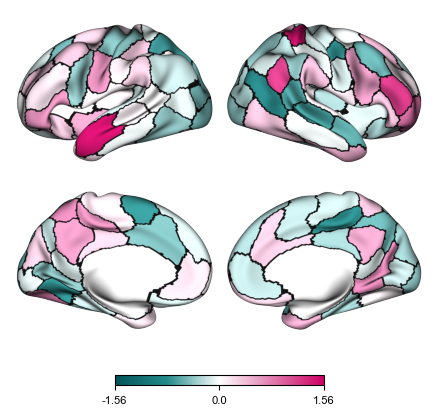

In [17]:
# Sum connectivity per node
diff_sum_LV1 = difference_matrix.sum(axis=1)

# Calculate maximum for range of connections
abs_max_cleaned_LV1 = np.nanmax(np.abs(diff_sum_LV1))

# Apply surface mapping function
surf_diff_sum_LV1 = data_to_surfdata(diff_sum_LV1, atlas,shift=True)

p = Plot(surf_lh=lh, surf_rh=rh, brightness=0.8)
p.add_layer(surf_diff_sum_LV1,
    cmap=custom_cmap,
    cbar=True,
    color_range=(-abs_max_cleaned_LV1, abs_max_cleaned_LV1),
    zero_transparent=False),
custom_outline = ListedColormap(["#000000FF",'#ffffff']) #black outline of regions"

p.add_layer(atlas,
    cmap=custom_outline,
    as_outline=True,
    cbar=False)

kws = {'fontsize': 8, 'shrink': 0.45}

fig = p.build(cbar_kws=kws)


### PLS Correlation between gene expression per node and psychopathology-relevant connectivity contrast per node

In [18]:
# Differences node sum PLS model
from sklearn.preprocessing import StandardScaler

# Save as data frame
diff_sum_LV1 = pd.DataFrame(diff_sum_LV1, columns=['Node_diff_sum_LV1'])

# Check for NaN values
print(f"Number of NaN values in abagen: {abagen_mock.isna().sum().sum()}"),
print(f"Number of NaN values in LV1: {diff_sum_LV1.isna().sum().sum()}"),


# Select only left hemisphere (first 50 nodes)
abagen_left = abagen_mock.iloc[:50, :]
diff_sum_LV1_left = diff_sum_LV1.iloc[:50, :]
 
# Scale
abagen_scaled_left = StandardScaler().fit_transform(abagen_left)
diff_sum_LV1_scaled_left = StandardScaler().fit_transform(diff_sum_LV1_left)


print(f"Shape of abagen_scaled: {abagen_scaled_left.shape}")
print(f"Shape of diff_sum_LV1_scaled: {diff_sum_LV1_scaled_left.shape}")

Number of NaN values in abagen: 0
Number of NaN values in LV1: 0
Shape of abagen_scaled: (50, 500)
Shape of diff_sum_LV1_scaled: (50, 1)


In [19]:
#pls_abagen_diff_mock = pyls.behavioral_pls(
#    abagen_scaled_left,
#    diff_sum_LV1_scaled_left,
#    n_perm=5000,
#    n_boot=1000)

#joblib.dump(pls_abagen_diff_mock, 'pls_abagen_diff_mock.joblib')

In [20]:
# load pls_abagen_diff_mock, model
pls_abagen_diff_mock = joblib.load('pls_abagen_diff_mock.joblib')
print("Variance Explained (%):")
print(pls_abagen_diff_mock.varexp * 100)
print("P-values:")
print(pls_abagen_diff_mock.permres.pvals)

Variance Explained (%):
[100.]
P-values:
[0.24915017]


In [21]:
# Extract weights and bootstrap ratios
raw_x_loadings = pls_abagen_diff_mock['x_weights']  # shape: (n_edges, n_LVs)
bootstrap_x_loadings = pls_abagen_diff_mock['bootres']['x_weights_normed']  # shape: (n_edges, n_LVs)

print(raw_x_loadings.shape)

(500, 1)


In [22]:
# Calculate loadings

gene_numeric = np.array(abagen_left, dtype=float)  # shape: (n_subjects, n_genes)
x_scores = pls_abagen_diff_mock.x_scores  # shape: (n_subjects, n_LVs)
n_genes = gene_numeric.shape[1]
n_LVs = x_scores.shape[1]

gene_loadings = np.zeros((n_genes, n_LVs))

for lv in range(n_LVs):
    for i in range(n_genes):
        gene_loadings[i, lv] = np.corrcoef(gene_numeric[:, i], x_scores[:, lv])[0, 1]

gene_bsr = pls_abagen_diff_mock.bootres.x_weights_normed[:, 0]  # LV1

print("Min:", np.min(gene_bsr))
print("Max:", np.max(gene_bsr))

Min: -5.003073816786905
Max: 5.904144811049234


In [23]:
# Threshold by BSR

gene_names = list(abagen_mock.columns) 
gene_names = np.array(gene_names)

bsr_threshold = 2.58 
stable_idx = np.abs(gene_bsr) >= bsr_threshold

gene_idx = stable_idx & (gene_loadings[:,0] !=0)

stable_genes_left = gene_names[gene_idx]

print(f"All stable genes: {len(stable_genes_left)}")

All stable genes: 17


In [24]:
print(stable_genes_left)

['gene7' 'gene34' 'gene49' 'gene51' 'gene56' 'gene65' 'gene140' 'gene218'
 'gene242' 'gene305' 'gene317' 'gene328' 'gene372' 'gene401' 'gene420'
 'gene435' 'gene470']


#### Load the list manually scoped from GWASs
GWASES were found for ADHD2022, Anxiety2024, Bipolar2024, BIP2-2021, MDD2025, PTSD2024, SUD2023. Not found for Autism2022 - paper does not share findings, details in manuscript.

In [25]:
with open("GWASlist_mock.txt", "r", encoding="utf-8-sig") as f:
    text = f.read()

genes_gwas_mock = [g.strip() for g in text.split(",") if g.strip()]

print(genes_gwas_mock)

['gene4', 'gene7', 'gene17', 'gene25', 'gene26', 'gene31', 'gene40', 'gene56', 'gene124', 'gene270', 'gene274', 'gene322', 'gene325', 'gene338', 'gene360', 'gene371', 'gene395', 'gene401', 'gene422', 'gene464', 'gene488', 'gene499']


In [26]:
# overlap
gene_overlap = set(genes_gwas_mock) & set(stable_genes_left)

print("How many overlapping genes:", len(gene_overlap))
print("Genes in ABAGEN PLS and GWAS:", gene_overlap)

How many overlapping genes: 3
Genes in ABAGEN PLS and GWAS: {np.str_('gene56'), np.str_('gene401'), np.str_('gene7')}


In [27]:
# Clear from duplicates for GOenrichment
genelist_gwas_clean = set(genes_gwas_mock)
genelist_abagenleft_clean = set(stable_genes_left)

print("Length of GWAS genes clean:", len(genelist_gwas_clean))
print("Length of ABAGEN PLS left hemi:", len(genelist_abagenleft_clean))

Length of GWAS genes clean: 22
Length of ABAGEN PLS left hemi: 17


In [28]:
# Save as txt files for g:Profiler
with open("genelist_gwas_clean.txt", "w") as f:
    f.write("\n".join(genelist_gwas_clean))

with open("genelist_abagenleft_clean.txt", "w") as f:
    f.write("\n".join(genelist_abagenleft_clean))